# 04 — Redes (gênero ↔ gênero, artista ↔ artista)

**O que vamos olhar e por quê.** O MGD+ já traz duas redes pré-calculadas:

- **Rede de gênero** (`data/MGDplus/genre_network/br/br-genre_network-YYYY.csv`): nó = gênero, aresta = co-ocorrência ponderada (quantas vezes os dois gêneros aparecem juntos como rótulos do mesmo artista).
- **Rede de artistas** (`data/MGDplus/artist_network/br/br-artist_network-YYYY.csv`): nó = artista, aresta = colaboração (peso = # de músicas em comum, com lista de song_ids).

Antes de empilhar isso num grafo heterogêneo, precisamos confirmar: as redes têm tamanho razoável? a maior componente cobre tudo? a distribuição de grau ajuda ou atrapalha (hubs gigantes)?

> **Nota técnica.** Os arquivos do `genre_network` são separados por **vírgula** e os do `artist_network` por **tab**. Aqui carregamos diretamente para evitar surpresas com o loader genérico.

In [1]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.cwd().resolve()
if ROOT.name == "exploration":
    ROOT = ROOT.parent
MGDPLUS = ROOT / "data" / "MGDplus"
GENRE_DIR = MGDPLUS / "genre_network" / "br"
ARTIST_DIR = MGDPLUS / "artist_network" / "br"

def load_genre_year(year: int) -> pd.DataFrame:
    return pd.read_csv(GENRE_DIR / f"br-genre_network-{year}.csv")  # comma-sep

def load_artist_year(year: int) -> pd.DataFrame:
    df = pd.read_csv(ARTIST_DIR / f"br-artist_network-{year}.csv", sep='\t')
    return df

YEARS = [2017, 2018, 2019, 2020, 2021, 2022]
print('genre files:', [p.name for p in sorted(GENRE_DIR.glob('*.csv'))])
print('artist files:', [p.name for p in sorted(ARTIST_DIR.glob('*.csv'))])

genre files: ['br-genre_network-2017.csv', 'br-genre_network-2018.csv', 'br-genre_network-2019.csv', 'br-genre_network-2020.csv', 'br-genre_network-2021.csv', 'br-genre_network-2022.csv']
artist files: ['br-artist_network-2017.csv', 'br-artist_network-2018.csv', 'br-artist_network-2019.csv', 'br-artist_network-2020.csv', 'br-artist_network-2021.csv', 'br-artist_network-2022.csv']


## 1) Rede de gênero — estatísticas básicas por ano

In [2]:
rows = []
for y in YEARS:
    df = load_genre_year(y)
    G = nx.from_pandas_edgelist(df, 'Source', 'Target', edge_attr='Weight')
    rows.append({
        'ano': y,
        'nós': G.number_of_nodes(),
        'arestas': G.number_of_edges(),
        'densidade': round(nx.density(G), 4),
        'componentes': nx.number_connected_components(G),
        'maior componente': len(max(nx.connected_components(G), key=len)),
        'peso médio': round(df['Weight'].mean(), 2),
        'peso máx': int(df['Weight'].max()),
    })
stats_genre = pd.DataFrame(rows)
print('Rede de gênero por ano:')
print(stats_genre.to_string(index=False))

Rede de gênero por ano:
 ano  nós  arestas  densidade  componentes  maior componente  peso médio  peso máx
2017  237     2061     0.0737            3               234        3.18       107
2018  264     2364     0.0681            1               264        3.19       103
2019  234     1859     0.0682            4               229        3.48       101
2020  262     1880     0.0550            2               260        4.72       264
2021  245     1514     0.0507            1               245        5.43       379
2022  148      828     0.0761            1               148        4.01       117


Top 10 gêneros por força (weighted degree) — 2020:
funk carioca               1085
brazilian hip hop           800
rap                         715
sertanejo universitario     645
pop nacional                634
latin pop                   574
mexican pop                 568
trap                        541
arrocha                     504
pop                         496


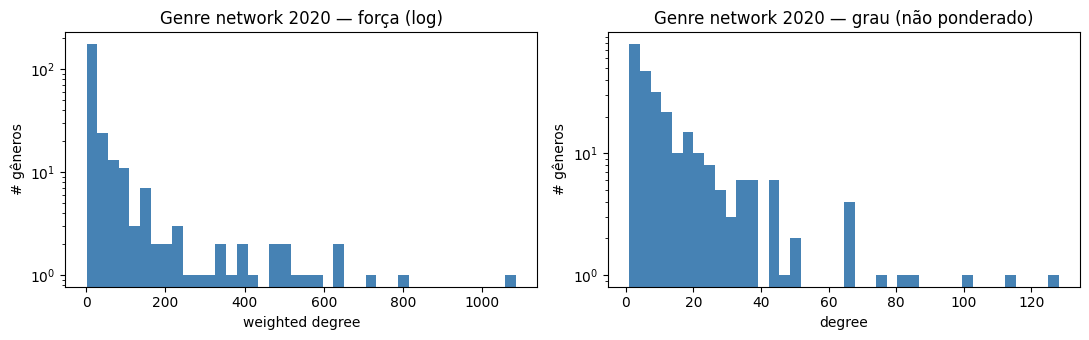

In [3]:
# Distribuição de grau ponderado e top gêneros — usando o ano mais denso (geralmente 2018 ou 2020)
year = 2020
df_g = load_genre_year(year)
G = nx.from_pandas_edgelist(df_g, 'Source', 'Target', edge_attr='Weight')

weighted_deg = pd.Series(dict(G.degree(weight='Weight'))).sort_values(ascending=False)
print(f'Top 10 gêneros por força (weighted degree) — {year}:')
print(weighted_deg.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(weighted_deg.values, bins=40, color='steelblue')
axes[0].set_yscale('log'); axes[0].set_title(f'Genre network {year} — força (log)')
axes[0].set_xlabel('weighted degree'); axes[0].set_ylabel('# gêneros')

axes[1].hist([d for _, d in G.degree()], bins=40, color='steelblue')
axes[1].set_yscale('log'); axes[1].set_title(f'Genre network {year} — grau (não ponderado)')
axes[1].set_xlabel('degree'); axes[1].set_ylabel('# gêneros')
plt.tight_layout(); plt.show()

## 2) Rede de artistas — estatísticas básicas por ano

In [4]:
rows = []
for y in YEARS:
    df = load_artist_year(y)
    G = nx.from_pandas_edgelist(df, 'artist_1', 'artist_2', edge_attr='count')
    rows.append({
        'ano': y,
        'nós': G.number_of_nodes(),
        'arestas': G.number_of_edges(),
        'densidade': round(nx.density(G), 4),
        'componentes': nx.number_connected_components(G),
        'maior componente': len(max(nx.connected_components(G), key=len)) if G.number_of_nodes() > 0 else 0,
        'colab média': round(df['count'].mean(), 2),
        'colab máx': int(df['count'].max()),
    })
stats_artist = pd.DataFrame(rows)
print('Rede de artistas por ano:')
print(stats_artist.to_string(index=False))

Rede de artistas por ano:
 ano  nós  arestas  densidade  componentes  maior componente  colab média  colab máx
2017  380      545     0.0076           38               280         1.26          6
2018  500      900     0.0072           36               397         1.19          6
2019  480      864     0.0075           45               367         1.17          6
2020  569     1268     0.0078           48               427         1.76         33
2021  657     1531     0.0071           55               479         1.28         27
2022  337      709     0.0125           43               203         1.15          9


**Leitura:** se a maior componente cobrir só uma fração modesta dos nós, é sinal de que a rede de colaboração é fragmentada (muitos artistas isolados) — o que era de esperar dado a cauda longa do notebook 03. Hubs com colaboração máxima alta (Alok, Dennis, etc.) são pontes naturais entre subcomunidades.

## 3) Visualização do subgrafo top-30 (gêneros, 2020)

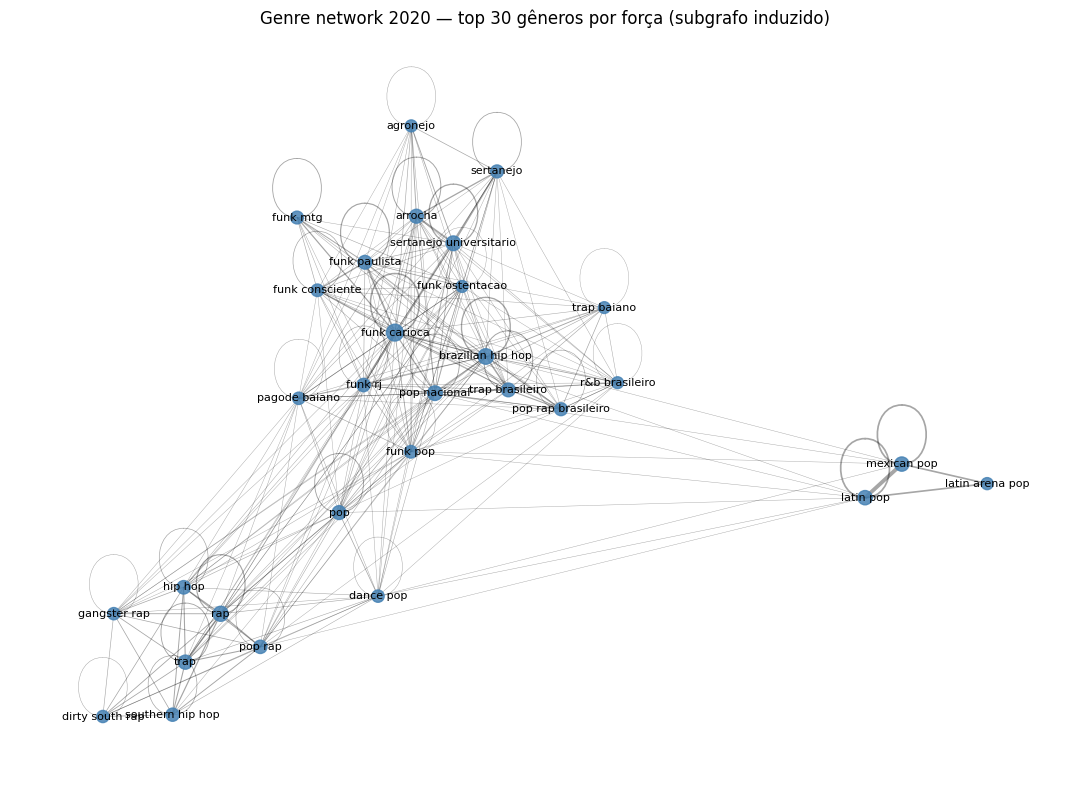

In [5]:
G = nx.from_pandas_edgelist(load_genre_year(2020), 'Source', 'Target', edge_attr='Weight')
weighted_deg = pd.Series(dict(G.degree(weight='Weight'))).sort_values(ascending=False)
top_nodes = weighted_deg.head(30).index.tolist()
H = G.subgraph(top_nodes)

pos = nx.spring_layout(H, seed=42, k=0.6, weight='Weight')
fig, ax = plt.subplots(figsize=(11, 8))
weights = [d['Weight'] for _, _, d in H.edges(data=True)]
max_w = max(weights) if weights else 1
edge_widths = [0.3 + 2.5 * w / max_w for w in weights]
node_sizes = [60 + 12 * weighted_deg[n] / weighted_deg.head(30).min() for n in H.nodes()]

nx.draw_networkx_edges(H, pos, alpha=0.35, width=edge_widths, ax=ax)
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color='steelblue', alpha=0.85, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=8, ax=ax)
ax.set_title('Genre network 2020 — top 30 gêneros por força (subgrafo induzido)')
ax.axis('off')
plt.tight_layout(); plt.show()

## 4) A rede muda muito entre 2017 e 2021?

Pergunta importante para o GNN temporal: o conjunto de nós/arestas é estável ano a ano, ou a topologia se transforma? Se for estável, dá para usar uma rede agregada como esqueleto; se mudar muito, faz sentido modelar arestas dinâmicas.

In [6]:
def edge_set(df, a='Source', b='Target'):
    return set(map(tuple, np.sort(df[[a, b]].values, axis=1)))

g17 = edge_set(load_genre_year(2017))
g21 = edge_set(load_genre_year(2021))
jaccard_g = len(g17 & g21) / len(g17 | g21) if (g17 | g21) else 0

a17 = edge_set(load_artist_year(2017), 'artist_1', 'artist_2')
a21 = edge_set(load_artist_year(2021), 'artist_1', 'artist_2')
jaccard_a = len(a17 & a21) / len(a17 | a21) if (a17 | a21) else 0

print(f'Jaccard de arestas 2017↔2021:')
print(f'  genre  network: {jaccard_g:.3f}  (|2017∪2021|={len(g17 | g21):,})')
print(f'  artist network: {jaccard_a:.3f}  (|2017∪2021|={len(a17 | a21):,})')

Jaccard de arestas 2017↔2021:
  genre  network: 0.165  (|2017∪2021|=3,069)
  artist network: 0.009  (|2017∪2021|=2,057)


**Leitura:** Jaccard alto (>0.5) na rede de gênero indica esqueleto estável (categorias musicais não somem ano a ano). Jaccard baixo na rede de artistas é esperado — colaborações pontuais não se repetem.

## Insight para o GNN

1. **Aresta `genre↔genre`** (peso = `Weight`/co-ocorrência): rede pequena (~150-300 nós), densa, **estável** ano a ano. Pode ser tratada como **esqueleto estático** — uma só rede agregada do período é suficiente.
2. **Aresta `artist↔artist`** (peso = `count`/colaborações): bem mais esparsa, fragmentada. Vale **podar peso=1** para reduzir ruído (decidir empiricamente em Phase 1).
3. **Hubs:** alguns gêneros (sertanejo, funk, pagode) e alguns artistas (Alok, Dennis, etc.) vão dominar o grau. **Cuidado com message passing**: GNN naive sofre com hubs (over-smoothing). Vale considerar GAT/SAGE com sampling em vez de GCN puro.
4. **Esqueleto temporal:** se Phase 2 for um GNN temporal (ex: HeteroGraphSAGE+GRU), a topologia pode ficar quase fixa, com **só os pesos das arestas variando por janela** (ano ou trimestre).